# Café Belén — Test de Features XGBoost
## ¿Qué hace este notebook?
Prueba **cada feature nueva de a una** y mide cuánto mejora (o empeora) el SMAPE.
Así sabemos exactamente cuál agregar y cuál descartar.

**Orden de ejecución:** corré todas las celdas de arriba a abajo. Al final hay una tabla comparativa automática.


## 1. Instalación e imports

In [9]:
# Instalá si no tenés: pip install xgboost pandas openpyxl scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_absolute_error, mean_squared_error
try:
    import xgboost as xgb
    USE_XGB = True
    print("✅ XGBoost listo")
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    USE_XGB = False
    print("⚠️  Usando GradientBoostingRegressor — instalá xgboost para mejores resultados")
print("✅ Imports OK")


✅ XGBoost listo
✅ Imports OK


## 2. Carga y preprocessing — Caso 3 + cohorte 2021-2022

Registros cargados: 5127
Negativos: 157 | Ceros: 53

Sucursales con cohorte ≤2022: 166
Serie mensual: 62 meses | Promedio: 3461 u/mes

Límite IQR: 8814
Meses outlier capeados: 2
  2021-08: 12378 → 8814
  2022-12: 13089 → 8814
IMPACTO DEL CAPEO IQR:
────────────────────────────────────────
Sin capeo  : SMAPE 26.85%
Con capeo  : SMAPE 22.37%
Mejora     : +4.48% puntos


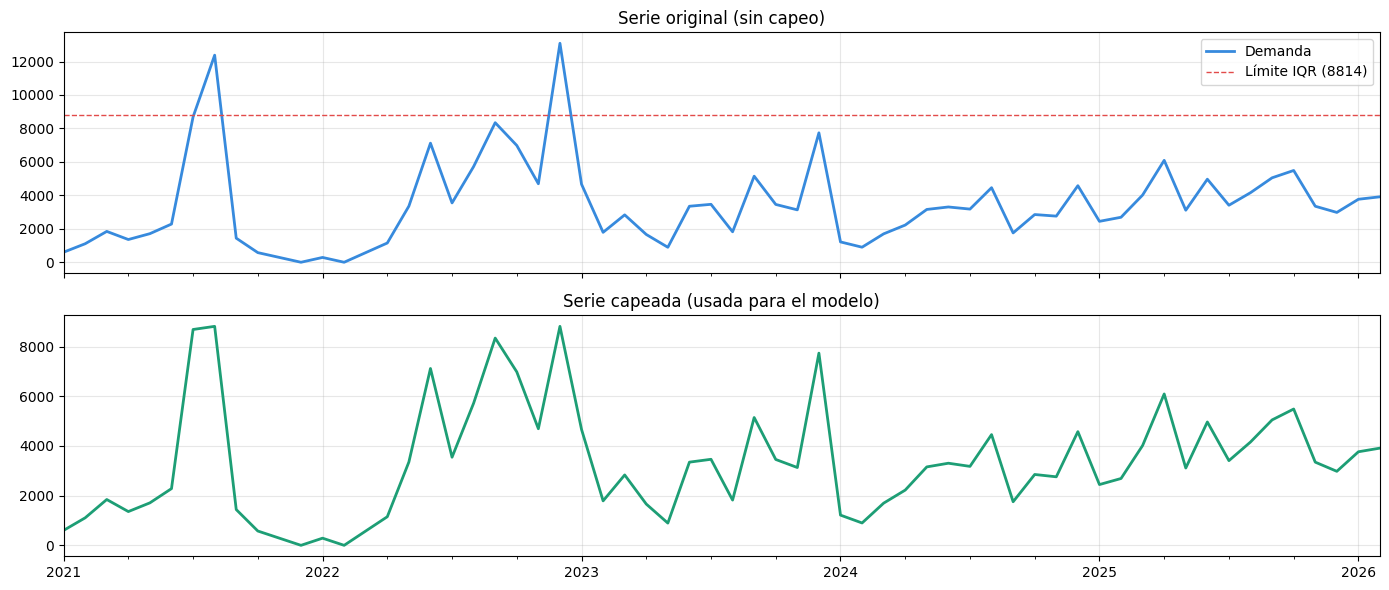


✅ Preprocessing listo. Usaremos la serie CAPEADA para todas las pruebas.


In [10]:
# ─── CONFIGURACIÓN ────────────────────────────────────────────
ARCHIVO  = "G:\My Drive\ElCapstone\Capstone\clari\CafeBelenTotal.xlsx"   # cambiá el path si es necesario
PRODUCTO = 281670015               # Café Belén

# Semana Santa en Paraguay por año (mes donde cae)
SEMANA_SANTA = {2021: 4, 2022: 4, 2023: 4, 2024: 3, 2025: 4, 2026: 4}
# ──────────────────────────────────────────────────────────────

df = pd.read_excel(ARCHIVO, sheet_name="Datos Producto")
df["Mes"] = pd.to_datetime(df["Mes"])
df = df[df["Producto"] == PRODUCTO].copy()
df = df.sort_values(["NomClienteAlter", "Mes"]).reset_index(drop=True)

print(f"Registros cargados: {len(df)}")
print(f"Negativos: {(df['Demanda']<0).sum()} | Ceros: {(df['Demanda']==0).sum()}")

# CASO 3: netear devoluciones contra mes anterior de la misma sucursal
for idx in df[df["Demanda"] < 0].index:
    cli   = df.loc[idx, "NomClienteAlter"]
    mes_d = df.loc[idx, "Mes"]
    dev   = df.loc[idx, "Demanda"]
    prev  = df[(df["NomClienteAlter"]==cli) & (df["Mes"]<mes_d)]
    if not prev.empty:
        pi = prev.index[-1]
        df.loc[pi, "Demanda"] = max(0, df.loc[pi, "Demanda"] + dev)
    df.loc[idx, "Demanda"] = 0

# COHORTE: solo sucursales abiertas hasta 2022
primera = df[df["Demanda"]>0].groupby("NomClienteAlter")["Mes"].min().rename("apertura")
df = df.merge(primera, on="NomClienteAlter")
df = df[df["apertura"].dt.year <= 2022].copy()

# Serie mensual
ts_raw = df.groupby("Mes")["Demanda"].sum().astype(float)
ts_raw = ts_raw.reindex(pd.date_range(ts_raw.index.min(), ts_raw.index.max(), freq="MS")).fillna(0.0)

print(f"\nSucursales con cohorte ≤2022: {df['NomClienteAlter'].nunique()}")
print(f"Serie mensual: {len(ts_raw)} meses | Promedio: {ts_raw.mean():.0f} u/mes")

# CAPEO IQR (solo Café Belén — tiene 2 meses outliers reales)
Q1  = ts_raw.quantile(0.25)
Q3  = ts_raw.quantile(0.75)
IQR = Q3 - Q1
LIM_IQR = float(Q3 + 1.5 * IQR)
outliers = ts_raw[ts_raw > LIM_IQR]
print(f"\nLímite IQR: {LIM_IQR:.0f}")
print(f"Meses outlier capeados: {len(outliers)}")
for fecha, val in outliers.items():
    print(f"  {fecha.strftime('%Y-%m')}: {val:.0f} → {LIM_IQR:.0f}")

ts_capeada = ts_raw.clip(upper=LIM_IQR)

# ── Comparación con/sin capeo ──────────────────
print("IMPACTO DEL CAPEO IQR:")
print("─" * 40)

# Sin capeo — usar ts_raw en lugar de ts_capeada
df_sincap = features_base(ts_raw).dropna().reset_index(drop=True)
a_sc, p_sc, _ = walk_forward(df_sincap)
m_sc = calcular_metricas(a_sc, p_sc, "Sin capeo")
print(f"Sin capeo  : SMAPE {m_sc['SMAPE']:.2f}%")

# Con capeo (lo que ya tenés)
print(f"Con capeo  : SMAPE {m0['SMAPE']:.2f}%")
print(f"Mejora     : {m_sc['SMAPE'] - m0['SMAPE']:+.2f}% puntos")

# Graficar serie original vs capeada
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ts_raw.plot(ax=axes[0], color="#378ADD", linewidth=2, title="Serie original (sin capeo)")
axes[0].axhline(LIM_IQR, color="#E24B4A", linestyle="--", linewidth=1, label=f"Límite IQR ({LIM_IQR:.0f})")
axes[0].legend(); axes[0].grid(alpha=0.3)
ts_capeada.plot(ax=axes[1], color="#1D9E75", linewidth=2, title="Serie capeada (usada para el modelo)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("\n✅ Preprocessing listo. Usaremos la serie CAPEADA para todas las pruebas.")


## 3. Funciones base — modelo, features, walk-forward, métricas

In [11]:
def construir_modelo():
    if USE_XGB:
        return xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                 subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                                 reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0)
    return GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=4, subsample=0.8, random_state=42)

def features_base(ts):
    """
    Features temporales + lags + rolling + YoY.
    Estas son la BASE — a partir de acá probamos agregar features nuevas.
    """
    df = pd.DataFrame({"y": ts.astype(float)}).reset_index()
    df.columns = ["fecha", "y"]
    df["mes_num"]    = df["fecha"].dt.month
    df["trimestre"]  = df["fecha"].dt.quarter
    df["año"]        = df["fecha"].dt.year
    df["t"]          = range(len(df))
    df["t2"]         = df["t"] ** 2
    for lag in [1, 2, 3, 4, 6, 12, 13, 24]:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    for v in [3, 6, 12]:
        df[f"roll_mean_{v}"] = df["y"].shift(1).rolling(v).mean()
        df[f"roll_std_{v}"]  = df["y"].shift(1).rolling(v).std()
        df[f"roll_max_{v}"]  = df["y"].shift(1).rolling(v).max()
    df["yoy_change"]  = df["y"].shift(1) - df["y"].shift(13)
    df["yoy_ratio"]   = df["y"].shift(1) / (df["y"].shift(13) + 1)
    df["ratio_trend"] = (df["y"].shift(1).rolling(3).mean() /
                        (df["y"].shift(1).rolling(12).mean() + 1))
    df["diff_1"] = df["y"].diff(1)
    return df

def walk_forward(df_feat, min_train=24, ventana=36):
    """
    Walk-Forward CV: entrena con el pasado, predice el siguiente mes.
    Nunca ve el futuro — simula el modelo en producción real.
    """
    fc = [c for c in df_feat.columns if c not in ["fecha", "y"]]
    X  = df_feat[fc].values
    y  = df_feat["y"].values
    fechas = df_feat["fecha"].values
    actuals, preds, dates = [], [], []
    for i in range(min_train, len(df_feat)):
        start = max(0, i - ventana)
        model = construir_modelo()
        model.fit(X[start:i], y[start:i])
        pred = max(0.0, float(model.predict(X[i:i+1])[0]))
        preds.append(pred)
        actuals.append(float(y[i]))
        dates.append(pd.Timestamp(fechas[i]))
    return np.array(actuals), np.array(preds), dates

def calcular_metricas(actuals, preds, label=""):
    mae   = mean_absolute_error(actuals, preds)
    rmse  = np.sqrt(mean_squared_error(actuals, preds))
    mask  = actuals > 0
    mape  = np.mean(np.abs((actuals[mask]-preds[mask])/actuals[mask]))*100
    smape = np.mean(2*np.abs(actuals-preds)/(np.abs(actuals)+np.abs(preds)+1e-9))*100
    bias  = np.mean(preds - actuals)
    ss_r  = np.sum((actuals-preds)**2)
    ss_t  = np.sum((actuals-actuals.mean())**2)
    r2    = 1 - ss_r/ss_t if ss_t > 0 else float("nan")
    return dict(label=label, SMAPE=smape, MAE=mae, RMSE=rmse, Bias=bias, R2=r2, n=len(actuals))

def imprimir_metricas(m):
    print(f"  SMAPE : {m['SMAPE']:>6.2f}%  ← métrica principal")
    print(f"  MAE   : {m['MAE']:>7.1f} unidades/mes")
    print(f"  Bias  : {m['Bias']:>+8.1f}  (+ sobreestima / - subestima)")
    print(f"  R²    : {m['R2']:>7.3f}")

print("✅ Funciones listas")


✅ Funciones listas


## 4. Prueba de features — una por una

Cada celda prueba **una sola feature**. Al final de cada celda ves el SMAPE y si mejoró o empeoró vs la base.

> **Regla:** si el SMAPE baja → la feature ayuda, la dejamos.  
> Si el SMAPE sube → la feature agrega ruido, la descartamos.


### 4.0 — BASE (sin features nuevas)

In [12]:
print("=" * 50)
print("  0. BASE — sin features adicionales")
print("=" * 50)

df0 = features_base(ts_capeada).dropna().reset_index(drop=True)
a0, p0, d0 = walk_forward(df0)
m0 = calcular_metricas(a0, p0, "0. Base")
imprimir_metricas(m0)

SMAPE_BASE = m0["SMAPE"]
print(f"\n  → Este es el punto de referencia: {SMAPE_BASE:.2f}%")


  0. BASE — sin features adicionales
  SMAPE :  22.37%  ← métrica principal
  MAE   :   897.8 unidades/mes
  Bias  :   -378.8  (+ sobreestima / - subestima)
  R²    :  -0.245

  → Este es el punto de referencia: 22.37%


### 4.1 — Feature: Navidad (nov-dic = 1)
**Por qué la probamos:** Nov y dic son los meses de mayor demanda en productos de consumo masivo en Paraguay — lo mencionó Joaquín en la reunión. El modelo ya tiene `mes_num` pero un flag binario le comunica más directamente que esos meses son especiales.


In [13]:
print("=" * 50)
print("  1. + NAVIDAD (noviembre y diciembre = 1)")
print("=" * 50)

df1 = features_base(ts_capeada).copy()
df1["navidad"] = df1["fecha"].dt.month.isin([11, 12]).astype(int)
df1 = df1.dropna().reset_index(drop=True)

a1, p1, d1 = walk_forward(df1)
m1 = calcular_metricas(a1, p1, "1. + Navidad")
imprimir_metricas(m1)

delta = SMAPE_BASE - m1["SMAPE"]
if delta > 0:
    print(f"\n  ✅ MEJORA de {delta:.2f}% → AGREGAR esta feature")
elif delta < 0:
    print(f"\n  ❌ EMPEORA {abs(delta):.2f}% → DESCARTAR esta feature")
else:
    print(f"\n  🔵 Sin cambio → no aporta ni perjudica")


  1. + NAVIDAD (noviembre y diciembre = 1)
  SMAPE :  22.37%  ← métrica principal
  MAE   :   895.0 unidades/mes
  Bias  :   -371.3  (+ sobreestima / - subestima)
  R²    :  -0.153

  ✅ MEJORA de 0.00% → AGREGAR esta feature


### 4.2 — Feature: Semana Santa (mes variable por año)
**Por qué la probamos:** Joaquín mencionó Semana Santa como pico de demanda. La clave es que la fecha **cambia cada año** — a veces cae en marzo, a veces en abril. Con solo `mes_num` el modelo confunde ambos meses. Este flag usa la fecha exacta de cada año.


In [14]:
print("=" * 50)
print("  2. + SEMANA SANTA (mes variable por año)")
print("=" * 50)
print(f"  Semana Santa por año: {SEMANA_SANTA}")

df2 = features_base(ts_capeada).copy()
df2["semana_santa"] = df2.apply(
    lambda r: 1 if SEMANA_SANTA.get(r["fecha"].year) == r["fecha"].month else 0,
    axis=1
)
df2 = df2.dropna().reset_index(drop=True)

print(f"  Meses marcados como Semana Santa: {df2['semana_santa'].sum()}")

a2, p2, d2 = walk_forward(df2)
m2 = calcular_metricas(a2, p2, "2. + Semana Santa")
imprimir_metricas(m2)

delta = SMAPE_BASE - m2["SMAPE"]
if delta > 0:
    print(f"\n  ✅ MEJORA de {delta:.2f}% → AGREGAR esta feature")
elif delta < 0:
    print(f"\n  ❌ EMPEORA {abs(delta):.2f}% → DESCARTAR esta feature")
else:
    print(f"\n  🔵 Sin cambio → no aporta ni perjudica")


  2. + SEMANA SANTA (mes variable por año)
  Semana Santa por año: {2021: 4, 2022: 4, 2023: 4, 2024: 3, 2025: 4, 2026: 4}
  Meses marcados como Semana Santa: 3
  SMAPE :  22.51%  ← métrica principal
  MAE   :   904.3 unidades/mes
  Bias  :   -368.6  (+ sobreestima / - subestima)
  R²    :  -0.197

  ❌ EMPEORA 0.14% → DESCARTAR esta feature


### 4.3 — Feature: Temporada alta (oct-dic = 1)
**Por qué la probamos:** Joaquín mencionó "octubre-diciembre" como temporada de pico. Probamos un flag más amplio que navidad (agrega octubre también) para ver si captura mejor el inicio de la temporada alta.


In [15]:
print("=" * 50)
print("  3. + TEMPORADA ALTA (octubre, noviembre, diciembre = 1)")
print("=" * 50)

df3 = features_base(ts_capeada).copy()
df3["temporada_alta"] = df3["fecha"].dt.month.isin([10, 11, 12]).astype(int)
df3 = df3.dropna().reset_index(drop=True)

a3, p3, d3 = walk_forward(df3)
m3 = calcular_metricas(a3, p3, "3. + Temporada alta oct-dic")
imprimir_metricas(m3)

delta = SMAPE_BASE - m3["SMAPE"]
if delta > 0:
    print(f"\n  ✅ MEJORA de {delta:.2f}% → AGREGAR esta feature")
elif delta < 0:
    print(f"\n  ❌ EMPEORA {abs(delta):.2f}% → DESCARTAR esta feature")
else:
    print(f"\n  🔵 Sin cambio → no aporta ni perjudica")


  3. + TEMPORADA ALTA (octubre, noviembre, diciembre = 1)
  SMAPE :  22.30%  ← métrica principal
  MAE   :   894.5 unidades/mes
  Bias  :   -359.6  (+ sobreestima / - subestima)
  R²    :  -0.175

  ✅ MEJORA de 0.06% → AGREGAR esta feature


### 4.4 — Feature: Invierno paraguayo (jun-jul = 1)
**Por qué la probamos:** El invierno paraguayo (junio-julio) puede tener efecto en el consumo de café caliente. Probamos si mejora el modelo aunque el pico principal del café sea en diciembre.


In [16]:
print("=" * 50)
print("  4. + INVIERNO PARAGUAYO (junio y julio = 1)")
print("=" * 50)

df4 = features_base(ts_capeada).copy()
df4["invierno"] = df4["fecha"].dt.month.isin([6, 7]).astype(int)
df4 = df4.dropna().reset_index(drop=True)

a4, p4, d4 = walk_forward(df4)
m4 = calcular_metricas(a4, p4, "4. + Invierno jun-jul")
imprimir_metricas(m4)

delta = SMAPE_BASE - m4["SMAPE"]
if delta > 0:
    print(f"\n  ✅ MEJORA de {delta:.2f}% → AGREGAR esta feature")
elif delta < 0:
    print(f"\n  ❌ EMPEORA {abs(delta):.2f}% → DESCARTAR esta feature")
else:
    print(f"\n  🔵 Sin cambio → no aporta ni perjudica")


  4. + INVIERNO PARAGUAYO (junio y julio = 1)
  SMAPE :  22.72%  ← métrica principal
  MAE   :   910.8 unidades/mes
  Bias  :   -352.5  (+ sobreestima / - subestima)
  R²    :  -0.176

  ❌ EMPEORA 0.35% → DESCARTAR esta feature


### 4.5 — Mejor combinación: features que mejoraron juntas
**Cómo funciona:** tomamos solo las features que mejoraron individualmente y las combinamos. Si el resultado es mejor que cada una por separado → esa es la configuración final.


In [17]:
print("=" * 50)
print("  5. MEJOR COMBINACIÓN — features que mejoraron juntas")
print("=" * 50)
print("  (editá esta celda según qué features mejoraron arriba)")

df5 = features_base(ts_capeada).copy()

# ── Agregá acá solo las features que MEJORARON en los pasos anteriores ──
df5["navidad"] = df5["fecha"].dt.month.isin([11, 12]).astype(int)
#df5["semana_santa"] = df5.apply(lambda r: 1 if SEMANA_SANTA.get(r["fecha"].year) == r["fecha"].month else 0, axis=1)
df5["temporada_alta"] = df5["fecha"].dt.month.isin([10,11,12]).astype(int)
#df5["invierno"] = df5["fecha"].dt.month.isin([6,7]).astype(int)
# ────────────────────────────────────────────────────────────────────────

df5 = df5.dropna().reset_index(drop=True)
a5, p5, d5 = walk_forward(df5)
m5 = calcular_metricas(a5, p5, "5. Mejor combinación")
imprimir_metricas(m5)

delta = SMAPE_BASE - m5["SMAPE"]
if delta > 0:
    print(f"\n  ✅ MEJORA total de {delta:.2f}% vs base")
elif delta < 0:
    print(f"\n  ❌ La combinación empeora {abs(delta):.2f}% — revisar qué feature está sumando ruido")


  5. MEJOR COMBINACIÓN — features que mejoraron juntas
  (editá esta celda según qué features mejoraron arriba)
  SMAPE :  21.82%  ← métrica principal
  MAE   :   866.4 unidades/mes
  Bias  :   -420.1  (+ sobreestima / - subestima)
  R²    :  -0.109

  ✅ MEJORA total de 0.55% vs base


## 5. Tabla comparativa — todas las configuraciones

In [18]:
todas = [m0, m1, m2, m3, m4, m5]
df_res = pd.DataFrame(todas)[["label","SMAPE","MAE","Bias","R2"]]
df_res = df_res.sort_values("SMAPE").reset_index(drop=True)
df_res.index += 1

print("=" * 65)
print("  RANKING — menor SMAPE = mejor")
print("=" * 65)
print(df_res.to_string(float_format=lambda x: f"{x:.2f}"))
print("=" * 65)

ganador = df_res.iloc[0]
print(f"\n🏆 MEJOR: {ganador['label']}")
print(f"   SMAPE: {ganador['SMAPE']:.2f}% | MAE: {ganador['MAE']:.1f} | Bias: {ganador['Bias']:+.1f}")
print(f"   Mejora vs base: {SMAPE_BASE - ganador['SMAPE']:+.2f}% puntos de SMAPE")


  RANKING — menor SMAPE = mejor
                         label  SMAPE    MAE    Bias    R2
1         5. Mejor combinación  21.82 866.40 -420.10 -0.11
2  3. + Temporada alta oct-dic  22.30 894.47 -359.62 -0.17
3                 1. + Navidad  22.37 895.04 -371.33 -0.15
4                      0. Base  22.37 897.83 -378.83 -0.25
5            2. + Semana Santa  22.51 904.31 -368.65 -0.20
6        4. + Invierno jun-jul  22.72 910.80 -352.52 -0.18

🏆 MEJOR: 5. Mejor combinación
   SMAPE: 21.82% | MAE: 866.4 | Bias: -420.1
   Mejora vs base: +0.55% puntos de SMAPE


## 6. Gráfico — real vs predicho (configuración ganadora)

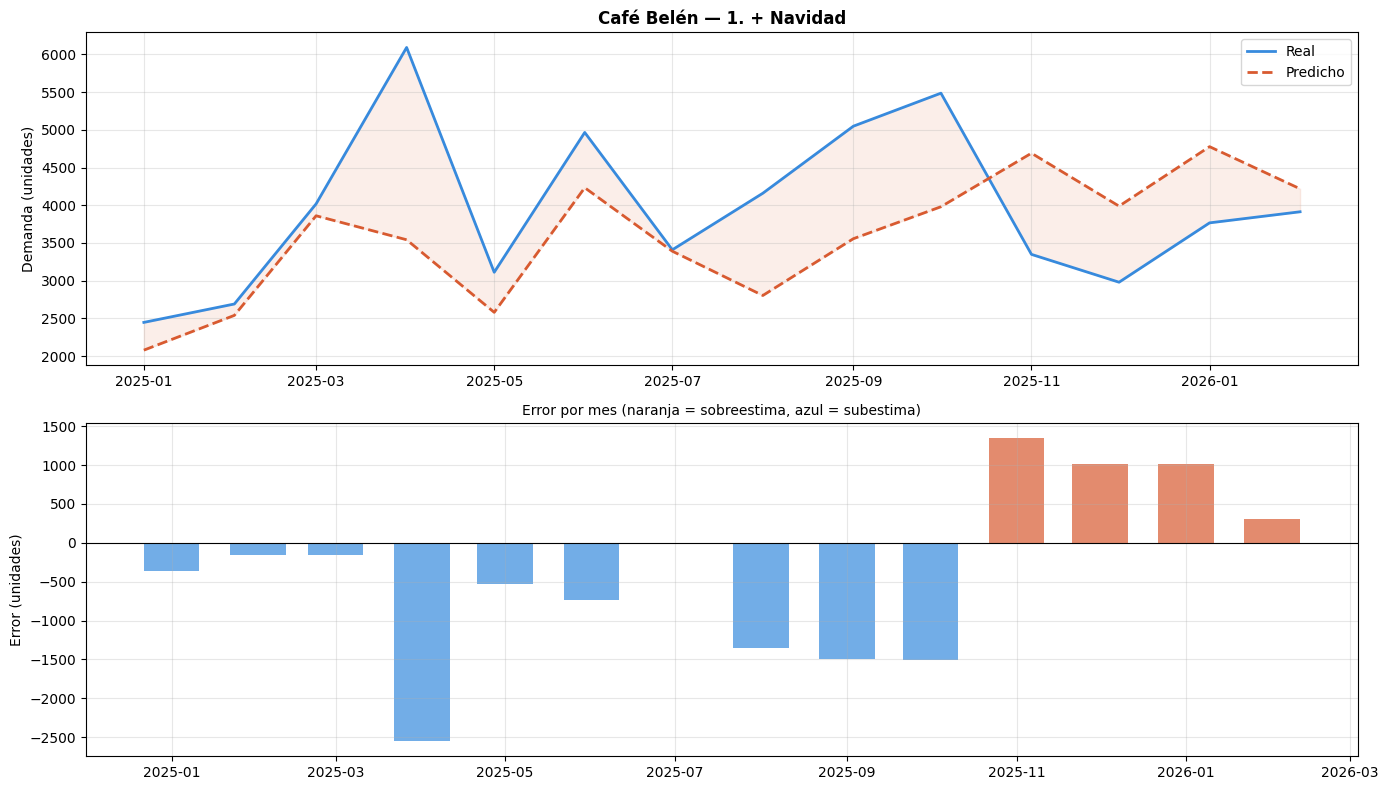

In [19]:
# Tomamos la mejor configuración del ranking
# Si la base fue la mejor, usamos a0/p0/d0
# Si otra fue mejor, cambiá a0→a5, p0→p5, d0→d5 según corresponda

# ── Editá esta línea con la mejor configuración ──
actuals_final, preds_final, dates_final = a1, p1, d1  # cambiar según ganador
label_final = m1["label"]
# ──────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Real vs predicho
axes[0].plot(dates_final, actuals_final, label="Real", color="#378ADD", linewidth=2)
axes[0].plot(dates_final, preds_final, label="Predicho", color="#D85A30",
             linewidth=2, linestyle="--")
axes[0].fill_between(dates_final, actuals_final, preds_final, alpha=0.1, color="#D85A30")
axes[0].set_title(f"Café Belén — {label_final}", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Demanda (unidades)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Error por mes
errores = np.array(preds_final) - np.array(actuals_final)
colores = ["#D85A30" if e > 0 else "#378ADD" for e in errores]
axes[1].bar(dates_final, errores, color=colores, alpha=0.7, width=20)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Error por mes (naranja = sobreestima, azul = subestima)", fontsize=10)
axes[1].set_ylabel("Error (unidades)"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Resumen — copiá esto al notebook de comparación final

In [20]:
# Usá los resultados del ganador
m_final = m1  # ← cambiá por la mejor métrica

print("=" * 55)
print("  RESUMEN CAFÉ BELÉN — para comparacion_final.ipynb")
print("=" * 55)
print(f"  Preprocessing : Caso 3 + cohorte ≤2022 + capeo IQR")
print(f"  Feature extra : {m_final['label']}")
print(f"  SMAPE  : {m_final['SMAPE']:.2f}%")
print(f"  MAE    : {m_final['MAE']:.1f} unidades/mes")
print(f"  RMSE   : {m_final['RMSE']:.1f}")
print(f"  Bias   : {m_final['Bias']:+.1f}")
print(f"  R²     : {m_final['R2']:.3f}")
print(f"  N      : {m_final['n']} meses evaluados")
print("=" * 55)


  RESUMEN CAFÉ BELÉN — para comparacion_final.ipynb
  Preprocessing : Caso 3 + cohorte ≤2022 + capeo IQR
  Feature extra : 1. + Navidad
  SMAPE  : 22.37%
  MAE    : 895.0 unidades/mes
  RMSE   : 1126.7
  Bias   : -371.3
  R²     : -0.153
  N      : 14 meses evaluados
